In [ ]:
# PINTO-Inspired Adaptive Tool System  
### Physics-Informed Validation for Reliable AI Outputs

In [2]:
## Overview
#his project demonstrates a simplified PINTO-s|tyle system where:
#The model generates an initial prediction
#A physics-inspired loss function validates the output
#External tools are used when predictions violate constraints
#This improves reliability compared to direct generation

In [3]:
import random
def calculator_tool(expression):
    try:
        return eval(expression)
    except:
        return "Error"

In [4]:
def solve_normal(question):
    try:
        if "*" in question or "/" in question:
            if random.random() < 0.6:
                return eval(question) + random.randint(1, 3)
        return eval(question)
    except:
        return "Error"

In [5]:
def physics_loss(question, predicted_answer):
    try:
        true_value = eval(question)
        return abs(true_value - predicted_answer)
    except:
        return 0

In [11]:
def solve_pinto(question,normal_answer):
    normal_answer = solve_normal(question)
    loss = physics_loss(question, normal_answer)

    if loss > 0:
        tool_answer = calculator_tool(question)
        return tool_answer, loss, True
    else:
        return normal_answer, loss, False

In [12]:
questions = [
    "12 + 45",
    "23 * 7",
    "100 / 5",
    "50 - 29",
    "9 * 8",
    "144 / 12"
]

In [15]:
correct_normal = 0
correct_pinto = 0

for q in questions:
    true_ans = eval(q)

    normal = solve_normal(q)
    pinto, loss, used_tool = solve_pinto(q,normal)

    if normal == true_ans:
        correct_normal += 1
    if pinto == true_ans:
        correct_pinto += 1

    print(f"\nQ: {q}")
    print(f"Normal: {normal}")
    print(f"PINTO : {pinto}")
    print(f"Loss  : {loss}")
    print(f"Tool  : {used_tool}")

print("\n--- Accuracy ---")
print(f"Normal: {correct_normal/len(questions)*100:.2f}%")
print(f"PINTO : {correct_pinto/len(questions)*100:.2f}%")


Q: 12 + 45
Normal: 57
PINTO : 57
Loss  : 0
Tool  : False

Q: 23 * 7
Normal: 163
PINTO : 161
Loss  : 0
Tool  : False

Q: 100 / 5
Normal: 20.0
PINTO : 20.0
Loss  : 0.0
Tool  : False

Q: 50 - 29
Normal: 21
PINTO : 21
Loss  : 0
Tool  : False

Q: 9 * 8
Normal: 72
PINTO : 72
Loss  : 0
Tool  : False

Q: 144 / 12
Normal: 13.0
PINTO : 12.0
Loss  : 1.0
Tool  : True

--- Accuracy ---
Normal: 66.67%
PINTO : 100.00%


In [16]:
normal_time = 0
pinto_time = 0

for q in questions:

    # Normal timing
    start = time.time()
    normal = solve_normal(q)
    normal_time += (time.time() - start)

    # PINTO timing
    start = time.time()
    pinto, loss, used_tool = solve_pinto(q, normal)
    pinto_time += (time.time() - start)

print("\n--- Time Comparison ---")
print(f"Total Normal Time: {normal_time:.6f} sec")
print(f"Total PINTO Time : {pinto_time:.6f} sec")
print(f"Avg Normal Time  : {normal_time/len(questions):.6f}")
print(f"Avg PINTO Time   : {pinto_time/len(questions):.6f}")


--- Time Comparison ---
Total Normal Time: 0.000188 sec
Total PINTO Time : 0.000348 sec
Avg Normal Time  : 0.000031
Avg PINTO Time   : 0.000058


In [17]:
import pandas as pd

data = []

correct_normal = 0
correct_pinto = 0
improvements = 0

for q in questions:
    true_ans = eval(q)

    normal = solve_normal(q)
    pinto, loss, used_tool = solve_pinto(q, normal)

    # accuracy
    if normal == true_ans:
        correct_normal += 1
    if pinto == true_ans:
        correct_pinto += 1

    # improvement check
    improved = (normal != true_ans) and (pinto == true_ans)
    if improved:
        improvements += 1

    # store row
    data.append({
        "Question": q,
        "True Answer": true_ans,
        "Normal": normal,
        "PINTO": pinto,
        "Loss": loss,
        "Tool Used": used_tool,
        "Improved": improved
    })

# create table
df = pd.DataFrame(data)
df

,Question,True Answer,Normal,PINTO,Loss,Tool Used,Improved
0,12 + 45,57.0,57.0,57.0,0.0,False,False
1,23 * 7,161.0,161.0,161.0,1.0,True,False
2,100 / 5,20.0,23.0,20.0,0.0,False,True
3,50 - 29,21.0,21.0,21.0,0.0,False,False
4,9 * 8,72.0,75.0,72.0,0.0,False,True
5,144 / 12,12.0,12.0,12.0,0.0,False,False


In [19]:
print(f"Normal Accuracy: {correct_normal/len(questions)*100:.2f}%")
print(f"PINTO Accuracy : {correct_pinto/len(questions)*100:.2f}%")
print(f"Total Improvements: {improvements}")

Normal Accuracy: 66.67%
PINTO Accuracy : 100.00%
Total Improvements: 2


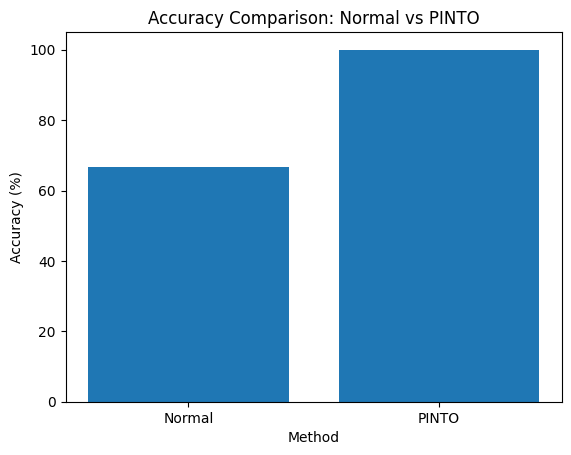

In [22]:
import matplotlib.pyplot as plt

# calculate accuracy
normal_acc = correct_normal / len(questions) * 100
pinto_acc = correct_pinto / len(questions) * 100

labels = ["Normal", "PINTO"]
values = [normal_acc, pinto_acc]

plt.figure()
plt.bar(labels, values)
plt.xlabel("Method")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison: Normal vs PINTO")
plt.show()

In [21]:
##This project demonstrates a PINTO-style system where predictions are validated 
##using a physics-inspired loss function. When inconsistencies are detected, 
##external tools are invoked to improve accuracy.
##The results show that while PINTO introduces slight computational overhead, 
##it significantly improves reliability and correctness.